# MultiHeadAttention with Weight Splits

Previously , We did a sequential causal attentions and concatenated to get final context vector

Now, 

1. Instead of maintaining 2 seperate classes - MultiHeadAttentionWrapper and CausalAttention, we combined both of these into a single Class

2. By utilizing the parallel power of matrix multiplication

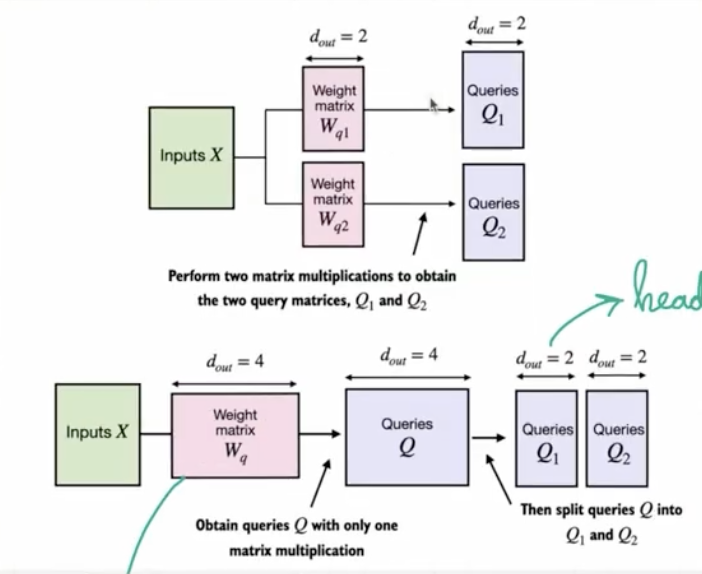

## Head_dimension = d_out / num_heads

In [27]:
import torch
import torch.nn as nn

class MultiHeadAttention(nn.Module):
    
    def __init__(self,d_in,d_out,context_length,dropout,num_heads,qkv_bias=False):
        super().__init__()

        assert (d_out%num_heads == 0), \
            "d_out must be divisible by num_heads"


        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads


        self.W_query = nn.Linear(d_in,d_out,bias = qkv_bias)
        self.W_key = nn.Linear(d_in,d_out,bias = qkv_bias)
        self.W_value = nn.Linear(d_in,d_out,bias=qkv_bias)

        self.out_proj = nn.Linear(d_out,d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask",
            torch.triu(torch.ones(context_length,context_length),diagonal=1)
        )

    def forward(self,x):
        b, num_tokens,d_in = x.shape

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)


        ## Shape of keys, queries, values is now batch_size * context_length * d_out
        ## split this into batch_size * context_length * num_heads * head_dim
        keys =  keys.view(b,num_tokens,self.num_heads,self.head_dim)
        queries = queries.view(b,num_tokens,self.num_heads,self.head_dim)
        values = values.view(b,num_tokens,self.num_heads,self.head_dim)


        ## We need to appoly attention for context_length * head_dim
        ## So lets transpose to shift those to last dimensions
        keys = keys.transpose(1,2)
        queries = queries.transpose(1,2)
        values = values.transpose(1,2)


        ## Attention scores
        attn_scores = queries @ keys.transpose(2,3)

        ## Masking
        mask_bool = self.mask.bool()[:num_tokens,:num_tokens]
        attn_scores.masked_fill_(mask_bool,-torch.inf)

        ## Attention Weights
        attn_weights = torch.softmax(attn_scores/keys.shape[-1]**0.5, dim=-1)

        ## Dropout
        attn_weights=self.dropout(attn_weights)

        ## Context Vector
        context_vec = (attn_weights @ values).transpose(1,2)

        ## Reshape Context Vector back
        context_vec=context_vec.contiguous().view(b,num_tokens,self.d_out)

        ## Optional Projection
        # context_vec = self.out_proj(context_vec)
        
        return context_vec

In [28]:
import torch

inputs = torch.tensor(
    [[0.43, 0.15, 0.89],  # Your      (x^1)
     [0.55, 0.87, 0.66],  # journey   (x^2)
     [0.57, 0.85, 0.64],  # starts    (x^3)
     [0.22, 0.58, 0.33],  # with      (x^4)
     [0.77, 0.25, 0.10],  # one       (x^5)
     [0.05, 0.80, 0.55]]  # step      (x^6)
)

inputs = torch.stack([inputs,inputs],dim=0)
print(inputs.shape)

torch.manual_seed(123)
context_length = inputs.shape[1]
d_in = 3
d_out = 4
num_heads=2


mha = MultiHeadAttention(d_in,d_out,context_length,0,num_heads=2)
mha.forward(inputs)

torch.Size([2, 6, 3])


tensor([[[-0.3132, -0.2272,  0.4772,  0.1063],
         [-0.2308,  0.0329,  0.5764,  0.3007],
         [-0.2059,  0.1190,  0.6097,  0.3654],
         [-0.1642,  0.1340,  0.5431,  0.3503],
         [-0.1689,  0.1794,  0.5296,  0.3389],
         [-0.1407,  0.1699,  0.5040,  0.3403]],

        [[-0.3132, -0.2272,  0.4772,  0.1063],
         [-0.2308,  0.0329,  0.5764,  0.3007],
         [-0.2059,  0.1190,  0.6097,  0.3654],
         [-0.1642,  0.1340,  0.5431,  0.3503],
         [-0.1689,  0.1794,  0.5296,  0.3389],
         [-0.1407,  0.1699,  0.5040,  0.3403]]], grad_fn=<ViewBackward0>)

In [30]:
torch.manual_seed(123)

# Define the tensor with 3 rows and 6 columns
inputs = torch.tensor(
    [[0.43, 0.15, 0.89, 0.55, 0.87, 0.66],  # Row 1
     [0.57, 0.85, 0.64, 0.22, 0.58, 0.33],  # Row 2
     [0.77, 0.25, 0.10, 0.05, 0.80, 0.55]]  # Row 3
)

batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape) 

batch_size, context_length, d_in = batch.shape
d_out = 6
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)


torch.Size([2, 3, 6])
tensor([[[-0.1354,  0.2538,  0.1353,  0.0993,  0.5164,  0.1103],
         [-0.2447,  0.3172, -0.0060,  0.1318,  0.6144,  0.0032],
         [-0.2898,  0.2501,  0.0070,  0.0092,  0.5663,  0.0665]],

        [[-0.1354,  0.2538,  0.1353,  0.0993,  0.5164,  0.1103],
         [-0.2447,  0.3172, -0.0060,  0.1318,  0.6144,  0.0032],
         [-0.2898,  0.2501,  0.0070,  0.0092,  0.5663,  0.0665]]],
       grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 3, 6])
